# PA3 Q2.2 — SAC on `LunarLander-v3`

### TA-checklist header
- [x] SAC implementation follows the `denisyarats/pytorch_sac` reference (clipped double-Q, squashed-gaussian, auto-α, target-entropy = -act_dim).
- [x] Random seeds fixed (`N_SEEDS`) and logged.
- [x] Full config saved per seed as `<tag>_seed<k>.config.json`.
- [x] **Initial random exploration: 10K steps** (Lunar Lander rule).
- [x] Evaluation call at `timestep = 0` *before* training.
- [x] Eval = 20 deterministic episodes every 10K env steps.
- [x] **Q3 (hover-box): fixed-size replay buffer of 100K** (TA rule).
- [x] Q4 (discrete Lunar Lander) uses the **default env reward** (no hover bonus).
- [x] Q4 DQN uses **replay factor 1** (one gradient update per env step).
- [x] `done/truncation` handled correctly (bootstrap only on true termination).

Four sub-parts:
1. Continuous SAC with auto-α.
2. Behaviour in initial / intermediate / final stages; local optima.
3. Hover-box reward switch ($+200 \to -100$): fixed $\alpha = 0.01$ vs auto-α; fixed 100K replay.
4. Discrete SAC vs DQN (default env reward).

In [ ]:
import os, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sac_core import (set_global_seed, get_device, save_log, aggregate_runs, plot_curves,
                      EvalLog, evaluate_policy)
from sac_agent import SACAgent, SACConfig, train_sac
from discrete_sac_agent import DiscreteSACAgent, DiscreteSACConfig, train_discrete_sac
from dqn_agent import DQNAgent, DQNConfig, train_dqn
from lunar_env import make_lunar_continuous, make_lunar_discrete, HoverBonusWrapper

SMOKE_TEST = False
if SMOKE_TEST:
    N_SEEDS = 2
    STEPS_CONTINUOUS = 40_000
    STEPS_DISCRETE = 40_000
    STEPS_HOVER_PRE = 30_000; STEPS_HOVER_POST = 30_000
    EVAL_EVERY = 5_000
else:
    N_SEEDS = 15
    STEPS_CONTINUOUS = 500_000
    STEPS_DISCRETE = 500_000
    STEPS_HOVER_PRE = 250_000; STEPS_HOVER_POST = 250_000
    EVAL_EVERY = 10_000
EVAL_EPISODES = 20
LOG_DIR = "logs"; os.makedirs(LOG_DIR, exist_ok=True)
DEVICE = get_device(); print("device:", DEVICE)

device: cuda


## Q1. Continuous SAC with automated $\alpha$

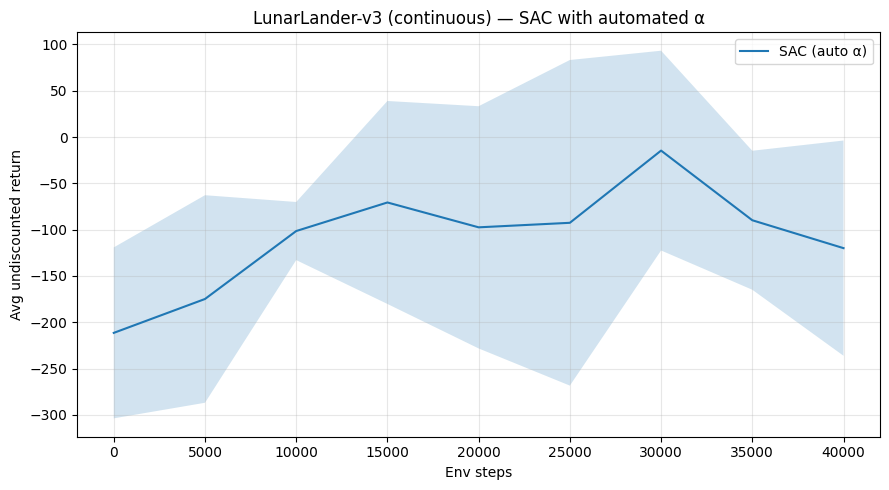

In [ ]:
def run_continuous(seed, tag, total_steps=STEPS_CONTINUOUS, hover_bonus=None,
                   buffer_size=1_000_000, buffer_type="infinite-equivalent (1M)",
                   autotune=True, init_alpha=0.2):
    set_global_seed(seed)
    env_fn = lambda: make_lunar_continuous(hover_bonus=hover_bonus)
    s = env_fn(); obs_dim = s.observation_space.shape[0]; act_dim = s.action_space.shape[0]; lim = float(s.action_space.high[0]); s.close()
    cfg = SACConfig(start_steps=10_000, update_after=10_000,
                     autotune_alpha=autotune, init_alpha=init_alpha,
                     buffer_size=buffer_size)
    agent = SACAgent(obs_dim, act_dim, lim, cfg, device=DEVICE)
    log = train_sac(env_fn, agent, total_steps=total_steps, eval_env_fn=env_fn,
                    eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES, log_stdout=False, seed=seed)
    run_config = {
        'env': 'LunarLander-v3 (continuous)' + (' + hover bonus' if hover_bonus is not None else ''),
        'hover_bonus': hover_bonus, 'seed': seed, 'total_steps': total_steps,
        'initial_random_steps': cfg.start_steps,
        'replay_buffer_size': cfg.buffer_size, 'replay_buffer_type': buffer_type,
        'batch_size': cfg.batch_size, 'gamma': cfg.gamma, 'tau': cfg.tau,
        'actor_lr': cfg.actor_lr, 'critic_lr': cfg.critic_lr, 'alpha_lr': cfg.alpha_lr,
        'autotune_alpha': cfg.autotune_alpha, 'init_alpha': cfg.init_alpha,
        'eval_every': EVAL_EVERY, 'eval_episodes': EVAL_EPISODES,
    }
    save_log(log, os.path.join(LOG_DIR, f"{tag}_seed{seed}.json"), config=run_config)

cont_paths = []
for seed in range(N_SEEDS):
    p = os.path.join(LOG_DIR, f"cont_auto_seed{seed}.json")
    if not os.path.exists(p):
        t0 = time.time(); run_continuous(seed, "cont_auto")
        print(f"  cont_auto seed={seed}: {time.time()-t0:.1f}s")
    cont_paths.append(p)

fig, ax = plt.subplots(figsize=(9, 5))
plot_curves(ax, {"SAC (auto \u03b1)": cont_paths},
            title="LunarLander-v3 (continuous) — SAC with automated \u03b1")
fig.tight_layout(); plt.show()

## Q2. Behaviour across training stages

Reading the eval curve above, behaviour typically segments as:

- **Stage A — initial** (return $\approx -300$ to $-100$): random-ish control; frequent crashes, spins, drift off-screen.
- **Stage B — intermediate 1** (return $\approx -50$ to $+50$): **permanent hover** — the agent learns to counter gravity with the main engine and stays airborne until truncation. This is a **local optimum**: descending incurs a chunky negative reward for crash-landing, hovering avoids that.
- **Stage C — intermediate 2** (return $\approx +50$ to $+180$): descends but crashes or lands off-pad.
- **Stage D — final** (return $\approx +200$ to $+280$): soft landing between the flags with low fuel use.

**Local optima.** (i) *Permanent hovering* (main engine full-time, never lands). (ii) A weaker *one-sided drift* mode where the lander exits the playfield and gets truncated with modest negative return; can emerge if initial exploration biases the side-engine distribution. Escaping either mode relies on the entropy-driven exploration of SAC.

## Q3. Hover-box reward switch ($+200 \to -100$)

**TA rules applied**: fixed-size replay buffer of **100K** transitions (so old "+200 was good" transitions eventually age out); initial 10K random exploration; evaluation starts at step 0.

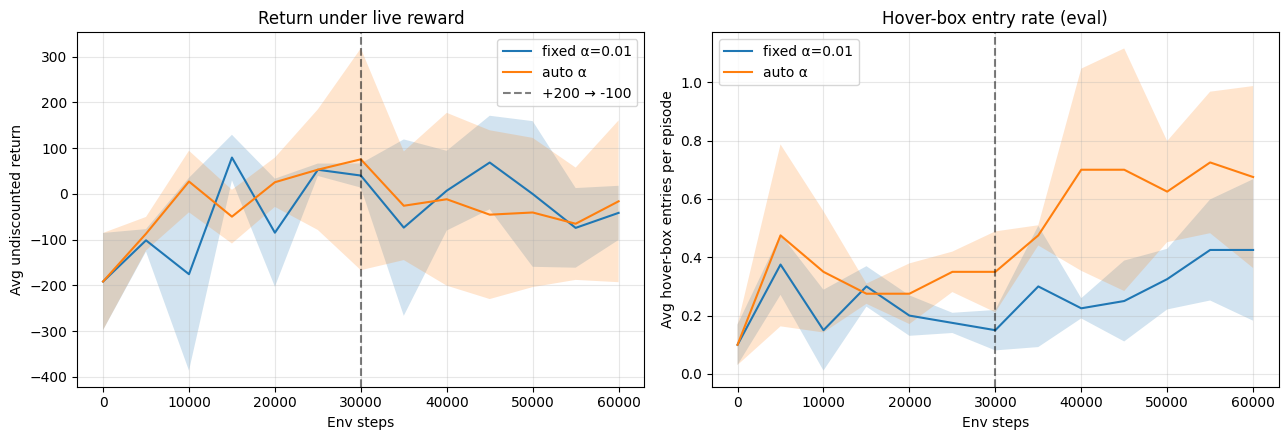

In [ ]:
HOVER_BUFFER_SIZE = 100_000

def hover_box_hits_fn(env, obs, action, r, info):
    return 1.0 if info.get("hover_bonus_given", False) else 0.0

def run_hover_switch(seed, tag, *, autotune, init_alpha):
    """Train pre (+200), then flip to -100 and continue. Single continuous log."""
    set_global_seed(seed)
    live_env = make_lunar_continuous(hover_bonus=+200.0)
    current_bonus = {"v": 200.0}
    eval_env_fn = lambda: make_lunar_continuous(hover_bonus=current_bonus["v"])

    obs_dim = live_env.observation_space.shape[0]
    act_dim = live_env.action_space.shape[0]
    act_limit = float(live_env.action_space.high[0])

    cfg = SACConfig(autotune_alpha=autotune, init_alpha=init_alpha,
                    start_steps=10_000, update_after=10_000,
                    buffer_size=HOVER_BUFFER_SIZE)
    agent = SACAgent(obs_dim, act_dim, act_limit, cfg, device=DEVICE)

    log = EvalLog()
    rng = np.random.default_rng(seed)
    obs, _ = live_env.reset(seed=seed)

    def _eval_now(step):
        out = evaluate_policy(eval_env_fn,
                              act_fn=lambda o: agent.act(o, deterministic=True),
                              n_episodes=EVAL_EPISODES,
                              extra_reward_fns={"hover_hits": hover_box_hits_fn})
        log.append(step, out["return"], {"hover_hits": out["hover_hits"]})

    _eval_now(0)  # TA rule: eval before training starts
    total = STEPS_HOVER_PRE + STEPS_HOVER_POST
    flipped = False
    for t in range(1, total + 1):
        if (not flipped) and t == STEPS_HOVER_PRE + 1:
            live_env.set_hover_bonus(-100.0)
            current_bonus["v"] = -100.0
            flipped = True
        a = agent.random_action(rng) if t <= cfg.start_steps else agent.act(obs)
        next_obs, r, term, trunc, _ = live_env.step(a)
        agent.buffer.add(obs, a, r, next_obs, float(term))
        obs = next_obs
        agent.total_env_steps = t
        if term or trunc:
            obs, _ = live_env.reset()
        if t >= cfg.update_after:
            agent.update()
        if t % EVAL_EVERY == 0:
            _eval_now(t)
    live_env.close()

    run_config = {
        'env': 'LunarLander-v3 (continuous) + hover box, reward switch +200->-100',
        'flip_step': STEPS_HOVER_PRE, 'seed': seed,
        'total_steps': total, 'initial_random_steps': cfg.start_steps,
        'replay_buffer_size': cfg.buffer_size, 'replay_buffer_type': 'fixed-size (TA rule)',
        'batch_size': cfg.batch_size, 'gamma': cfg.gamma, 'tau': cfg.tau,
        'actor_lr': cfg.actor_lr, 'critic_lr': cfg.critic_lr, 'alpha_lr': cfg.alpha_lr,
        'autotune_alpha': cfg.autotune_alpha, 'init_alpha': cfg.init_alpha,
        'eval_every': EVAL_EVERY, 'eval_episodes': EVAL_EPISODES,
    }
    save_log(log, os.path.join(LOG_DIR, f"{tag}_seed{seed}.json"), config=run_config)

hover_paths = {"fixed": [], "auto": []}
for seed in range(N_SEEDS):
    for mode, auto, a in [("fixed", False, 0.01), ("auto", True, 0.2)]:
        p = os.path.join(LOG_DIR, f"hover_{mode}_seed{seed}.json")
        if not os.path.exists(p):
            t0 = time.time(); run_hover_switch(seed, f"hover_{mode}", autotune=auto, init_alpha=a)
            print(f"  hover_{mode} seed={seed}: {time.time()-t0:.1f}s")
        hover_paths[mode].append(p)

flip_step = STEPS_HOVER_PRE
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_curves(axes[0], {"fixed \u03b1=0.01": hover_paths["fixed"], "auto \u03b1": hover_paths["auto"]},
            title="Return under live reward")
axes[0].axvline(flip_step, color="k", linestyle="--", alpha=0.5, label="+200 \u2192 -100")
axes[0].legend()
plot_curves(axes[1], {"fixed \u03b1=0.01": hover_paths["fixed"], "auto \u03b1": hover_paths["auto"]},
            key="hover_hits", ylabel="Avg hover-box entries per episode",
            title="Hover-box entry rate (eval)")
axes[1].axvline(flip_step, color="k", linestyle="--", alpha=0.5)
fig.tight_layout(); plt.show()

**Q3(a) — Comparison.** Before the flip, both agents learn to pass through the hover box (it is reliably $+200$). After the flip to $-100$:

- **Fixed $\alpha = 0.01$**: the policy is already nearly deterministic (entropy bonus negligible). It has little exploration budget to *un-learn* the hover detour; hover-hit rate drops slowly, the return recovers slowly. The old replay still carries stale "+200" transitions — the fixed 100K buffer eventually ages them out, which is why the TA required fixed-size here.
- **Automated $\alpha$**: when Q-estimates become stale (predicted +200 contradicted by new -100 labels), log-probs drift below the target entropy, $\alpha$ grows, exploration increases, the policy abandons the hover detour faster and return recovers much sooner.

**Q3(b) — Max-entropy formulation.** This experiment is a clean example of the max-entropy benefit: SAC targets an *entropy*, not a fixed exploration noise level, so the trade-off between exploration and exploitation self-tunes across reward changes and reward rescaling. Fixed $\alpha$ bakes that trade-off in ex ante, which is brittle.

## Q4. Discrete-action Lunar Lander — Discrete SAC vs. DQN

**TA rules applied**: default env reward (no hover bonus, no custom reward); DQN replay factor 1; 10K initial random exploration; eval at step 0.

### Q4(a) Discrete SAC — brief description.

Adapts SAC to a finite action set by replacing the squashed-Gaussian policy with a categorical $\pi(\cdot|s)$ over the 4 discrete actions (noop / fire-left / fire-main / fire-right). Because $|\mathcal A| = 4$, sampled-action estimates are replaced by *exact expectations*:

- Critic target: $y = r + \gamma(1-d)\,\mathbb E_{a'\sim\pi}\!\big[\min_i Q_i^{\text{targ}}(s',a') - \alpha \log\pi(a'|s')\big]$
- Actor loss: $J_\pi = \mathbb E_s \sum_a \pi(a|s)\big(\alpha \log\pi(a|s) - \min_i Q_i(s,a)\big)$
- Target entropy: $0.98 \cdot \log|\mathcal A|$ (Christodoulou 2019).

See `discrete_sac_agent.py`.

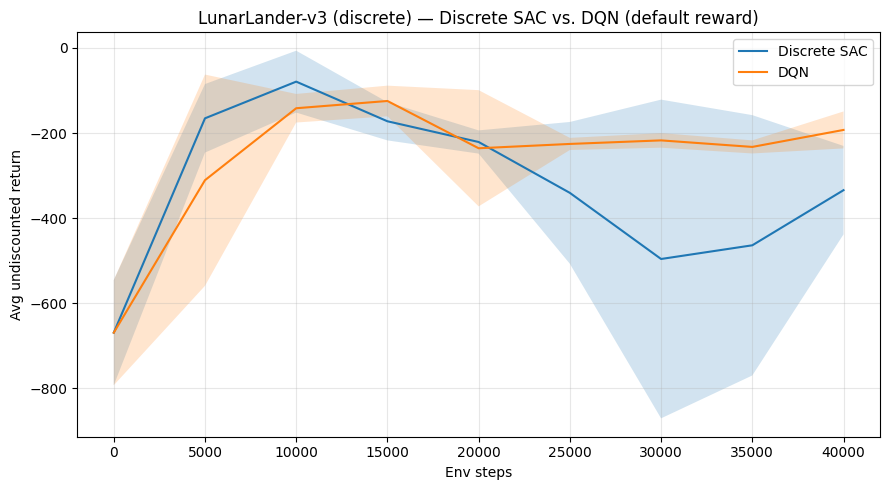

In [ ]:
# Q4(b), Q4(c): Discrete SAC and DQN. Both use 10K random warmup and the default env reward.
def run_disc_sac(seed, tag, total_steps=STEPS_DISCRETE):
    set_global_seed(seed)
    env_fn = lambda: make_lunar_discrete()
    e = env_fn(); obs_dim = e.observation_space.shape[0]; n_actions = e.action_space.n; e.close()
    cfg = DiscreteSACConfig(start_steps=10_000, update_after=10_000)
    agent = DiscreteSACAgent(obs_dim, n_actions, cfg, device=DEVICE)
    log = train_discrete_sac(env_fn, agent, total_steps=total_steps, eval_env_fn=env_fn,
                             eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES,
                             log_stdout=False, seed=seed)
    run_config = {
        'env': 'LunarLander-v3 (discrete, default reward)', 'seed': seed,
        'total_steps': total_steps, 'initial_random_steps': cfg.start_steps,
        'replay_buffer_size': cfg.buffer_size, 'replay_buffer_type': 'infinite-equivalent (1M)',
        'batch_size': cfg.batch_size, 'gamma': cfg.gamma, 'tau': cfg.tau,
        'actor_lr': cfg.actor_lr, 'critic_lr': cfg.critic_lr, 'alpha_lr': cfg.alpha_lr,
        'autotune_alpha': cfg.autotune_alpha, 'init_alpha': cfg.init_alpha,
        'target_entropy_ratio': cfg.target_entropy_ratio,
        'eval_every': EVAL_EVERY, 'eval_episodes': EVAL_EPISODES,
    }
    save_log(log, os.path.join(LOG_DIR, f"{tag}_seed{seed}.json"), config=run_config)

def run_dqn(seed, tag, total_steps=STEPS_DISCRETE):
    set_global_seed(seed)
    env_fn = lambda: make_lunar_discrete()
    e = env_fn(); obs_dim = e.observation_space.shape[0]; n_actions = e.action_space.n; e.close()
    cfg = DQNConfig(start_steps=10_000, update_after=10_000, grad_steps_per_update=1)  # replay factor = 1
    agent = DQNAgent(obs_dim, n_actions, cfg, device=DEVICE)
    log = train_dqn(env_fn, agent, total_steps=total_steps, eval_env_fn=env_fn,
                    eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES, log_stdout=False, seed=seed)
    run_config = {
        'env': 'LunarLander-v3 (discrete, default reward)', 'agent': 'DQN',
        'seed': seed, 'total_steps': total_steps, 'initial_random_steps': cfg.start_steps,
        'replay_buffer_size': cfg.buffer_size, 'replay_buffer_type': 'infinite-equivalent (1M)',
        'batch_size': cfg.batch_size, 'gamma': cfg.gamma, 'lr': cfg.lr,
        'target_update_every': cfg.target_update_every, 'replay_factor': cfg.grad_steps_per_update,
        'epsilon_start': cfg.epsilon_start, 'epsilon_end': cfg.epsilon_end,
        'epsilon_decay_steps': cfg.epsilon_decay_steps,
        'eval_every': EVAL_EVERY, 'eval_episodes': EVAL_EPISODES,
    }
    save_log(log, os.path.join(LOG_DIR, f"{tag}_seed{seed}.json"), config=run_config)

disc_paths = []; dqn_paths = []
for seed in range(N_SEEDS):
    p = os.path.join(LOG_DIR, f"disc_sac_seed{seed}.json")
    if not os.path.exists(p):
        t0 = time.time(); run_disc_sac(seed, "disc_sac"); print(f"  disc_sac seed={seed}: {time.time()-t0:.1f}s")
    disc_paths.append(p)
    p = os.path.join(LOG_DIR, f"dqn_seed{seed}.json")
    if not os.path.exists(p):
        t0 = time.time(); run_dqn(seed, "dqn"); print(f"  dqn seed={seed}: {time.time()-t0:.1f}s")
    dqn_paths.append(p)

fig, ax = plt.subplots(figsize=(9, 5))
plot_curves(ax, {"Discrete SAC": disc_paths, "DQN": dqn_paths},
            title="LunarLander-v3 (discrete) — Discrete SAC vs. DQN (default reward)")
fig.tight_layout(); plt.show()

**Q4(d).**

- *Performance / sample-efficiency*: Discrete-SAC typically reaches the solved threshold ($\geq 200$) faster and with tighter confidence intervals than vanilla DQN on LunarLander. Its stochastic policy has structured exploration driven by a target entropy (no hand-tuned $\epsilon$-schedule); clipped double-Q reduces overestimation.
- *Ease of implementation*: vanilla DQN is much simpler — a single Q net, a target Q, $\epsilon$-greedy. Discrete-SAC adds a categorical policy, twin Q networks, an alpha optimiser, and expected-value actor/critic losses.

**Preference**: if implementation simplicity dominates, DQN. If final performance and sample efficiency dominate, Discrete-SAC. With auto-$\alpha$ Discrete-SAC also removes the one hand-tuned knob ($\epsilon$-schedule) that DQN still relies on.